## Import the CIFAR-10


In [1]:
# libs needed

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim

import numpy as np

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# Things i change to test the NN
num_epochs = 1
batch_size = 160


# https://github.com/kuangliu/pytorch-cifar/issues/19 mean and std values calculated from the actual data set.
# mean =  (0.4914, 0.4822, 0.4465)
# std = (0.247, 0.243, 0.261)
mean = (0.5, 0.5, 0.5)
std = (0.5, 0.5, 0.5)

### data augmentation

In [3]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),  
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),  
    transforms.Normalize(mean, std)  # Normalize to -1 to 1
])


test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

## Load the data

In [4]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)


train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=10
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False, 
    num_workers=10
)

print("done loading")

/home/harald/Documents/uni_filer/8Sem/Kunstig intelligense værktøjer/Module4 - CNN/UV_env_jupyter/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


done loading


# Setting up the CNN


In [5]:

class HBBVGG(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32x32 --> 16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16x16 --> 8x8

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 8x8 --> 4x4

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 4x4 --> 2x2

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            # nn.MaxPool2d(kernel_size=2, stride=2) # No max-pooling to avoid going to small
        )

        # the three fully connected layers
        self.classifier = nn.Sequential(
            nn.Linear(512 * 2 * 2, 4096),  # the 512 dept * 2x2 spatial size
            nn.ReLU(inplace=True),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, 10),  # 10 classes as output --> cifar-10
            # nn.Softmax(dim=1) # removed because the crossentropy function
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1) 
        x = self.classifier(x)
        return x

# Training the model

In [ ]:
model = HBBVGG()
print(model)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []


def evaluate_model(model, data_loader): # made so i dont have to have dublicate code
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for Images, Labels in data_loader:
            outputs = model(Images)
            _, predicted = torch.max(outputs.data, 1)
            total += Labels.size(0)
            correct += (predicted == Labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy


for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for Images, Labels in train_loader:
        outputs = model(Images)
        loss = criterion(outputs, Labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    train_acc = evaluate_model(model, train_loader)
    train_accuracies.append(train_acc)
    
    # running test on the test data to find the loss and accuracy 
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for Images, Labels in test_loader:
            outputs = model(Images)
            val_loss += criterion(outputs, Labels).item()
    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    val_acc = evaluate_model(model, test_loader)
    val_accuracies.append(val_acc)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%')



plt.figure(figsize=(12, 4))
# loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.title('Training and Validation Loss')

# accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.grid()
plt.tight_layout()
plt.savefig('plots_dataAug_cifar_mean_std_30epoch_160batch.pdf')
plt.show()




HBBVGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False

NameError: name 'classes' is not defined

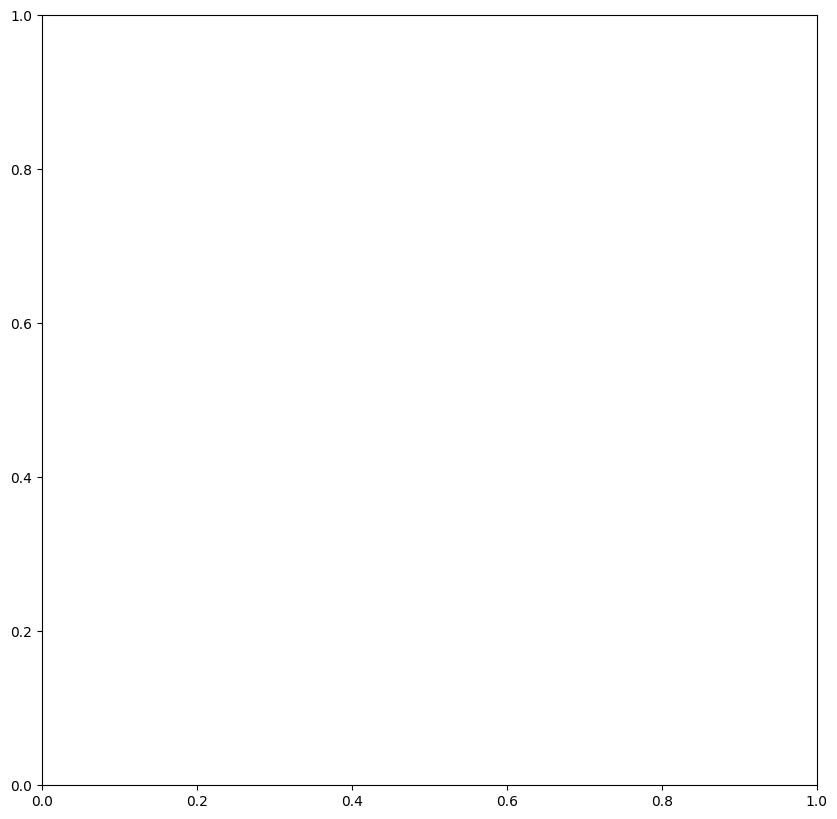

In [7]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())


cm = confusion_matrix(all_labels, all_predictions)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix - VGG-11 on CIFAR-10")
plt.savefig('confusion_matrix_dataAug_cifar_mean_std_30epoch_160batch.pdf')
plt.show()

